In [29]:
!pip install -q ipympl
get_ipython().kernel.do_shutdown(restart=True)

In [30]:
from google.colab import output
output.enable_custom_widget_manager()

In [32]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

In [33]:
# 10 Seconds Of Data With a Samping Rate Of 1 kHz. 4 Sine Waves, Each With Different Frequencies And Amplitudes.

sampling_rate = 1000
timepoints = 10 * sampling_rate
time_vector = np.arange(0, timepoints) / sampling_rate

frequencies = np.linspace(1, 30, 4)
amplitudes = np.linspace(1, 5, 4)

frequencies, amplitudes

(array([ 1.        , 10.66666667, 20.33333333, 30.        ]),
 array([1.        , 2.33333333, 3.66666667, 5.        ]))

In [34]:
# Generating Sine Waves With Different Frequencies And Amplitudes.

sinewaves = np.zeros((len(frequencies), timepoints))
for i in range(len(frequencies)):
  sinewaves[i, :] = amplitudes[i] * np.sin(2 * np.pi * frequencies[i] * time_vector)

sinewaves.shape

(4, 10000)

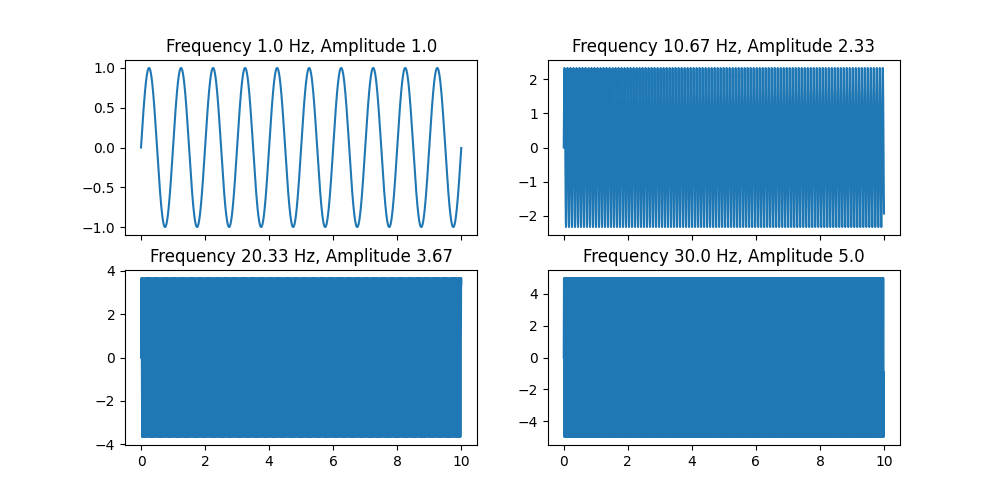

In [35]:
# Visualization Of Sine Waves

plt.close('all')
plt.subplots(2, 2, figsize=(10, 5), sharex=['cols'])
for i in range(len(frequencies)):
  plt.subplot(2, 2, i + 1)
  plt.plot(time_vector, sinewaves[i, :])
  plt.title(f'Frequency {np.round(frequencies[i], 2)} Hz, Amplitude {np.round(amplitudes[i], 2)}')
plt.show()

In [36]:
# Generating And Adding Random Noise
noise = np.random.randn(len(time_vector))
sine_noise = sinewaves + noise

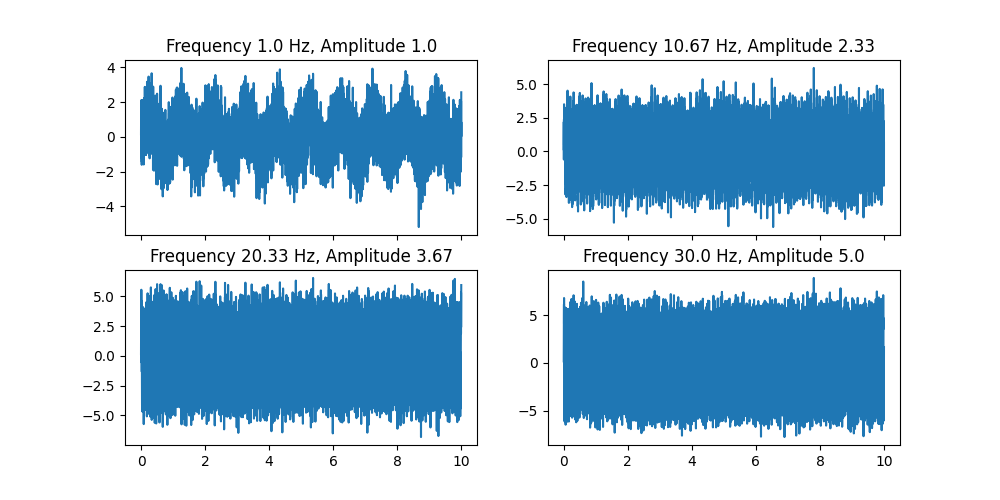

In [37]:
# Visualization Of Sine Waves With Added Noise

plt.close('all')
plt.subplots(2, 2, figsize=(10, 5), sharex=['cols'])
for i in range(len(frequencies)):
  plt.subplot(2, 2, i + 1)
  plt.plot(time_vector, sine_noise[i, :])
  plt.title(f'Frequency {np.round(frequencies[i], 2)} Hz, Amplitude {np.round(amplitudes[i], 2)}')
plt.show()

In [38]:
# Extracting Static Power Spectra
nyquist = int(sampling_rate / 2)
hz = np.linspace(0, nyquist, int(timepoints/2))
pw = np.zeros((len(frequencies), timepoints))

for i in range(len(frequencies)):
  f_coef = np.fft.fft(sine_noise[i]) / timepoints
  pw[i] = 2 ** np.abs(f_coef)

pw.shape

(4, 10000)

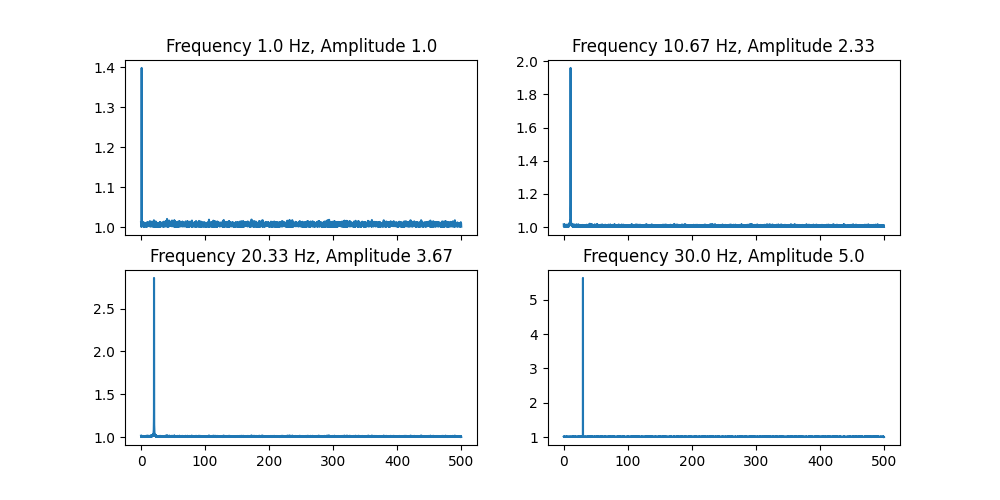

In [39]:
# Visuaizing Static Power. Frequencies On The X-Axis. Amplitudes On The Y-Axis

plt.close('all')
plt.subplots(2, 2, figsize=(10, 5), sharex=['cols'])
for i in range(len(frequencies)):
  plt.subplot(2, 2, i + 1)
  plt.plot(hz, pw[i, :len(hz)])
  plt.title(f'Frequency {np.round(frequencies[i], 2)} Hz, Amplitude {np.round(amplitudes[i], 2)}')
plt.show()